# Logistic Regression



## Concepts
1. Linear Model
    * Logistic Regression is just Linear Regresion however the y axis is converted using log(p/1-p), turning the y-axis into a axis of probablity.
    * Due to this, all the techiques and abilties of Linear Regression can be applied to Logestic Regression
2. L1 Regulariziation
    * Applies the 'L1' penalty of λ * |Slope| to model. 
    * This penalty can lower the weight of each X to 0, performing automatic feature selection. 
3. L2 Regulariziation
    * Applies the 'L2' penalty of λ^2 * Slope  to model. 
    * This penality can't bring weights to 0, but bring them to close it. It makes it so that all Xs entered have some weight in the final model.
    * Prevents Overfitting. Increases Bias for lower Variance.
    * This penality also reduces the amount of data needed. 
        * For Example, a model with 3 paramters would 3 data points, 10000 paramters means 10000 Data Points are needed to even star the model. This Penality removes this requirement, meaning you can fit a linear model even if you less data than paramters. 
4. Elastic Net
    * A Combination of L1 and L2 Regulariziation.
    * It has the benefits of both without most of its negatives.
    * The Penality term is λ1 * |Slope| + λ2^2 * Slope. Both λ values are different
5. Multiclass
    * Logestic Regression can do Multiclass Classification, by creating a logestic regression model for each output. Each model determines is if the probs that output is yes or no.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
X,y = load_wine(return_X_y=True)
X2,y2 = load_breast_cancer(return_X_y=True)

In [4]:
x = StandardScaler().fit_transform(X)

In [5]:
Cs = np.logspace(-3, 2, 30)

In [6]:
non_zeros = []
coefs = []
for c in Cs:
    clf = LogisticRegression(penalty='l1',solver='saga', l1_ratio=1, C=c, max_iter=5000)
    clf.fit(x,y)
    coef = clf.coef_.ravel()
    coefs.append(coef)
    non_zeros.append(np.sum(coef))

d:\User\Vakeesan's Pc\Download\DS Projects - Summer 2026\ML Learning Delivarbles\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\User\Vakeesan's Pc\Download\DS Projects - Summer 2026\ML Learning Delivarbles\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasti

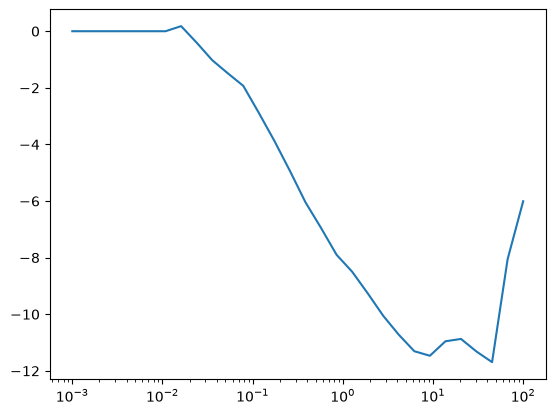

In [7]:
plt.plot(Cs, non_zeros)
plt.xscale('log')
plt.show()

# Model 1 - Breast Cancer

l2 vs l1

In [8]:
pipe1 = Pipeline([
    ("Scaler", StandardScaler()),
    ("Model", LogisticRegression(solver="saga"))
])

param_grid = {
    "Model__l1_ratio":[0,0.5,1] # For future note, 0 is L1, 1 is L2, and anything between 0 and 1 is elsastic net.
}
gs = GridSearchCV(
    estimator=pipe1,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy'
)


In [9]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2)

In [10]:
gs.fit(X_train, y_train)

d:\User\Vakeesan's Pc\Download\DS Projects - Summer 2026\ML Learning Delivarbles\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\User\Vakeesan's Pc\Download\DS Projects - Summer 2026\ML Learning Delivarbles\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\User\Vakeesan's Pc\Download\DS Projects - Summer 2026\ML Learning Delivarbles\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\User\Vakeesan's Pc\Download\DS Projects - Summer 2026\ML Learning Delivarbles\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\User\Vakeesan's Pc\Download\DS Projects -

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'Model__l1_ratio': [0, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fi

In [23]:
result = pd.DataFrame(gs.cv_results_).sort_values('rank_test_score')
result[['params', 'mean_test_score', 'rank_test_score']]

,params,mean_test_score,rank_test_score
0,{'Model__l1_ratio': 0},0.982464,1
2,{'Model__l1_ratio': 1},0.982464,1
1,{'Model__l1_ratio': 0.5},0.980290,3


In [20]:
y_pred = gs.best_estimator_.predict(X_test)
accuracy_score(y_true=y_test, y_pred=y_pred)

0.9166666666666666

For this datasest, l1 regularization performed the best, followed by Elastic Net and then L2 Regurlaziation.

Moving on, I am now going to test which regularization works best for multiclassfication

In [21]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, shuffle=True)

In [22]:
pipe1 = Pipeline([
    ("Scaler", StandardScaler()),
    ("Model", LogisticRegression(solver="saga"))
])

param_grid = {
    "Model__l1_ratio":[0,0.5,1] 
}
gs = GridSearchCV(
    estimator=pipe1,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy'
)

gs.fit(X2_train, y2_train)

d:\User\Vakeesan's Pc\Download\DS Projects - Summer 2026\ML Learning Delivarbles\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\User\Vakeesan's Pc\Download\DS Projects - Summer 2026\ML Learning Delivarbles\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\User\Vakeesan's Pc\Download\DS Projects - Summer 2026\ML Learning Delivarbles\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\User\Vakeesan's Pc\Download\DS Projects - Summer 2026\ML Learning Delivarbles\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\User\Vakeesan's Pc\Download\DS Projects -

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'Model__l1_ratio': [0, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fi

In [24]:
result = pd.DataFrame(gs.cv_results_).sort_values('rank_test_score')
result[['params', 'mean_test_score', 'rank_test_score']]

,params,mean_test_score,rank_test_score
0,{'Model__l1_ratio': 0},0.982464,1
2,{'Model__l1_ratio': 1},0.982464,1
1,{'Model__l1_ratio': 0.5},0.980290,3


l1 and l2 seem to have perform equal to each other in this case, while elastic net fell behind.

In [26]:
gs.best_score_

np.float64(0.9824637681159419)

In [27]:
y_pred= gs.best_estimator_.predict(X2_test)
accuracy_score(y2_test, y_pred)

0.9736842105263158